In [3]:
# !pip install xgboost
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics  import accuracy_score
import warnings
warnings.simplefilter('ignore')

In [5]:
df=pd.read_csv('Dry_Eye_Dataset.csv')
df

,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
0,F,24,9.5,2,1,137/89,67,3000,31,161,...,N,Y,Y,N,8.7,N,Y,Y,N,Y
1,M,39,9.6,2,3,108/64,60,12000,74,164,...,N,Y,Y,N,9.6,Y,N,N,Y,Y
2,F,45,5.4,1,5,134/81,95,12000,93,179,...,N,N,N,Y,4.0,N,Y,N,N,N
3,F,45,5.4,4,5,110/90,78,19000,32,160,...,N,Y,N,N,7.6,N,Y,N,Y,N
4,F,42,5.7,3,2,99/67,72,4000,173,179,...,N,Y,N,N,3.5,N,Y,Y,N,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,M,26,9.4,2,3,132/64,91,20000,88,200,...,Y,Y,Y,Y,3.8,N,Y,N,Y,Y
19996,F,39,7.3,3,4,101/75,65,2000,53,195,...,N,Y,Y,N,3.8,N,N,Y,N,Y
19997,F,20,8.0,5,3,124/63,78,10000,17,186,...,Y,Y,N,N,8.4,N,N,Y,N,N
19998,M,38,4.5,3,3,136/70,60,3000,115,170,...,Y,N,Y,N,2.2,N,N,N,Y,Y


In [7]:
df.shape

(20000, 26)

In [9]:
df.duplicated().sum()

0

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       20000 non-null  object 
 1   Age                          20000 non-null  int64  
 2   Sleep duration               20000 non-null  float64
 3   Sleep quality                20000 non-null  int64  
 4   Stress level                 20000 non-null  int64  
 5   Blood pressure               20000 non-null  object 
 6   Heart rate                   20000 non-null  int64  
 7   Daily steps                  20000 non-null  int64  
 8   Physical activity            20000 non-null  int64  
 9   Height                       20000 non-null  int64  
 10  Weight                       20000 non-null  int64  
 11  Sleep disorder               20000 non-null  object 
 12  Wake up during night         20000 non-null  object 
 13  Feel sleepy duri

In [13]:
df.dtypes

Gender                          object
Age                              int64
Sleep duration                 float64
Sleep quality                    int64
Stress level                     int64
Blood pressure                  object
Heart rate                       int64
Daily steps                      int64
Physical activity                int64
Height                           int64
Weight                           int64
Sleep disorder                  object
Wake up during night            object
Feel sleepy during day          object
Caffeine consumption            object
Alcohol consumption             object
Smoking                         object
Medical issue                   object
Ongoing medication              object
Smart device before bed         object
Average screen time            float64
Blue-light filter               object
Discomfort Eye-strain           object
Redness in eye                  object
Itchiness/Irritation in eye     object
Dry Eye Disease          

In [15]:
df.isna().sum()

Gender                         0
Age                            0
Sleep duration                 0
Sleep quality                  0
Stress level                   0
Blood pressure                 0
Heart rate                     0
Daily steps                    0
Physical activity              0
Height                         0
Weight                         0
Sleep disorder                 0
Wake up during night           0
Feel sleepy during day         0
Caffeine consumption           0
Alcohol consumption            0
Smoking                        0
Medical issue                  0
Ongoing medication             0
Smart device before bed        0
Average screen time            0
Blue-light filter              0
Discomfort Eye-strain          0
Redness in eye                 0
Itchiness/Irritation in eye    0
Dry Eye Disease                0
dtype: int64

In [17]:
df.isna().sum()/df.shape[0]*100

Gender                         0.0
Age                            0.0
Sleep duration                 0.0
Sleep quality                  0.0
Stress level                   0.0
Blood pressure                 0.0
Heart rate                     0.0
Daily steps                    0.0
Physical activity              0.0
Height                         0.0
Weight                         0.0
Sleep disorder                 0.0
Wake up during night           0.0
Feel sleepy during day         0.0
Caffeine consumption           0.0
Alcohol consumption            0.0
Smoking                        0.0
Medical issue                  0.0
Ongoing medication             0.0
Smart device before bed        0.0
Average screen time            0.0
Blue-light filter              0.0
Discomfort Eye-strain          0.0
Redness in eye                 0.0
Itchiness/Irritation in eye    0.0
Dry Eye Disease                0.0
dtype: float64

In [19]:
df.head()

,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
0,F,24,9.5,2,1,137/89,67,3000,31,161,...,N,Y,Y,N,8.7,N,Y,Y,N,Y
1,M,39,9.6,2,3,108/64,60,12000,74,164,...,N,Y,Y,N,9.6,Y,N,N,Y,Y
2,F,45,5.4,1,5,134/81,95,12000,93,179,...,N,N,N,Y,4.0,N,Y,N,N,N
3,F,45,5.4,4,5,110/90,78,19000,32,160,...,N,Y,N,N,7.6,N,Y,N,Y,N
4,F,42,5.7,3,2,99/67,72,4000,173,179,...,N,Y,N,N,3.5,N,Y,Y,N,Y


In [21]:
df.tail()

,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
19995,M,26,9.4,2,3,132/64,91,20000,88,200,...,Y,Y,Y,Y,3.8,N,Y,N,Y,Y
19996,F,39,7.3,3,4,101/75,65,2000,53,195,...,N,Y,Y,N,3.8,N,N,Y,N,Y
19997,F,20,8.0,5,3,124/63,78,10000,17,186,...,Y,Y,N,N,8.4,N,N,Y,N,N
19998,M,38,4.5,3,3,136/70,60,3000,115,170,...,Y,N,Y,N,2.2,N,N,N,Y,Y
19999,M,37,5.0,5,3,96/90,73,13000,57,188,...,N,Y,Y,Y,4.2,Y,N,N,N,N


In [23]:
df.columns

Index(['Gender', 'Age', 'Sleep duration', 'Sleep quality', 'Stress level',
       'Blood pressure', 'Heart rate', 'Daily steps', 'Physical activity',
       'Height', 'Weight', 'Sleep disorder', 'Wake up during night',
       'Feel sleepy during day', 'Caffeine consumption', 'Alcohol consumption',
       'Smoking', 'Medical issue', 'Ongoing medication',
       'Smart device before bed', 'Average screen time', 'Blue-light filter',
       'Discomfort Eye-strain', 'Redness in eye',
       'Itchiness/Irritation in eye', 'Dry Eye Disease'],
      dtype='object')

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,31.422800,8.103717,18.0,24.0,31.0,39.0,45.0
Sleep duration,20000.0,6.998245,1.731723,4.0,5.5,7.0,8.5,10.0
Sleep quality,20000.0,2.997250,1.412283,1.0,2.0,3.0,4.0,5.0
Stress level,20000.0,2.993750,1.407235,1.0,2.0,3.0,4.0,5.0
Heart rate,20000.0,79.912200,11.808279,60.0,70.0,80.0,90.0,100.0
Daily steps,20000.0,10536.900000,5752.729186,1000.0,6000.0,11000.0,16000.0,20000.0
Physical activity,20000.0,90.069750,52.317283,0.0,45.0,91.0,135.0,180.0
Height,20000.0,174.865900,14.719903,150.0,162.0,175.0,188.0,200.0
Weight,20000.0,74.891850,14.733839,50.0,62.0,75.0,88.0,100.0
Average screen time,20000.0,5.519885,2.606305,1.0,3.3,5.5,7.8,10.0


# EDA

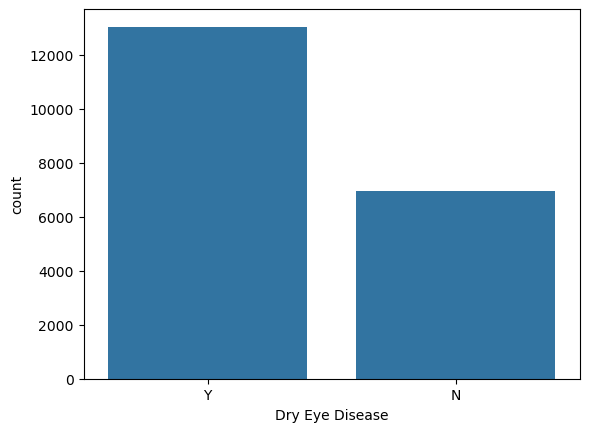

In [28]:
sns.countplot(data=df,x='Dry Eye Disease')
plt.show()

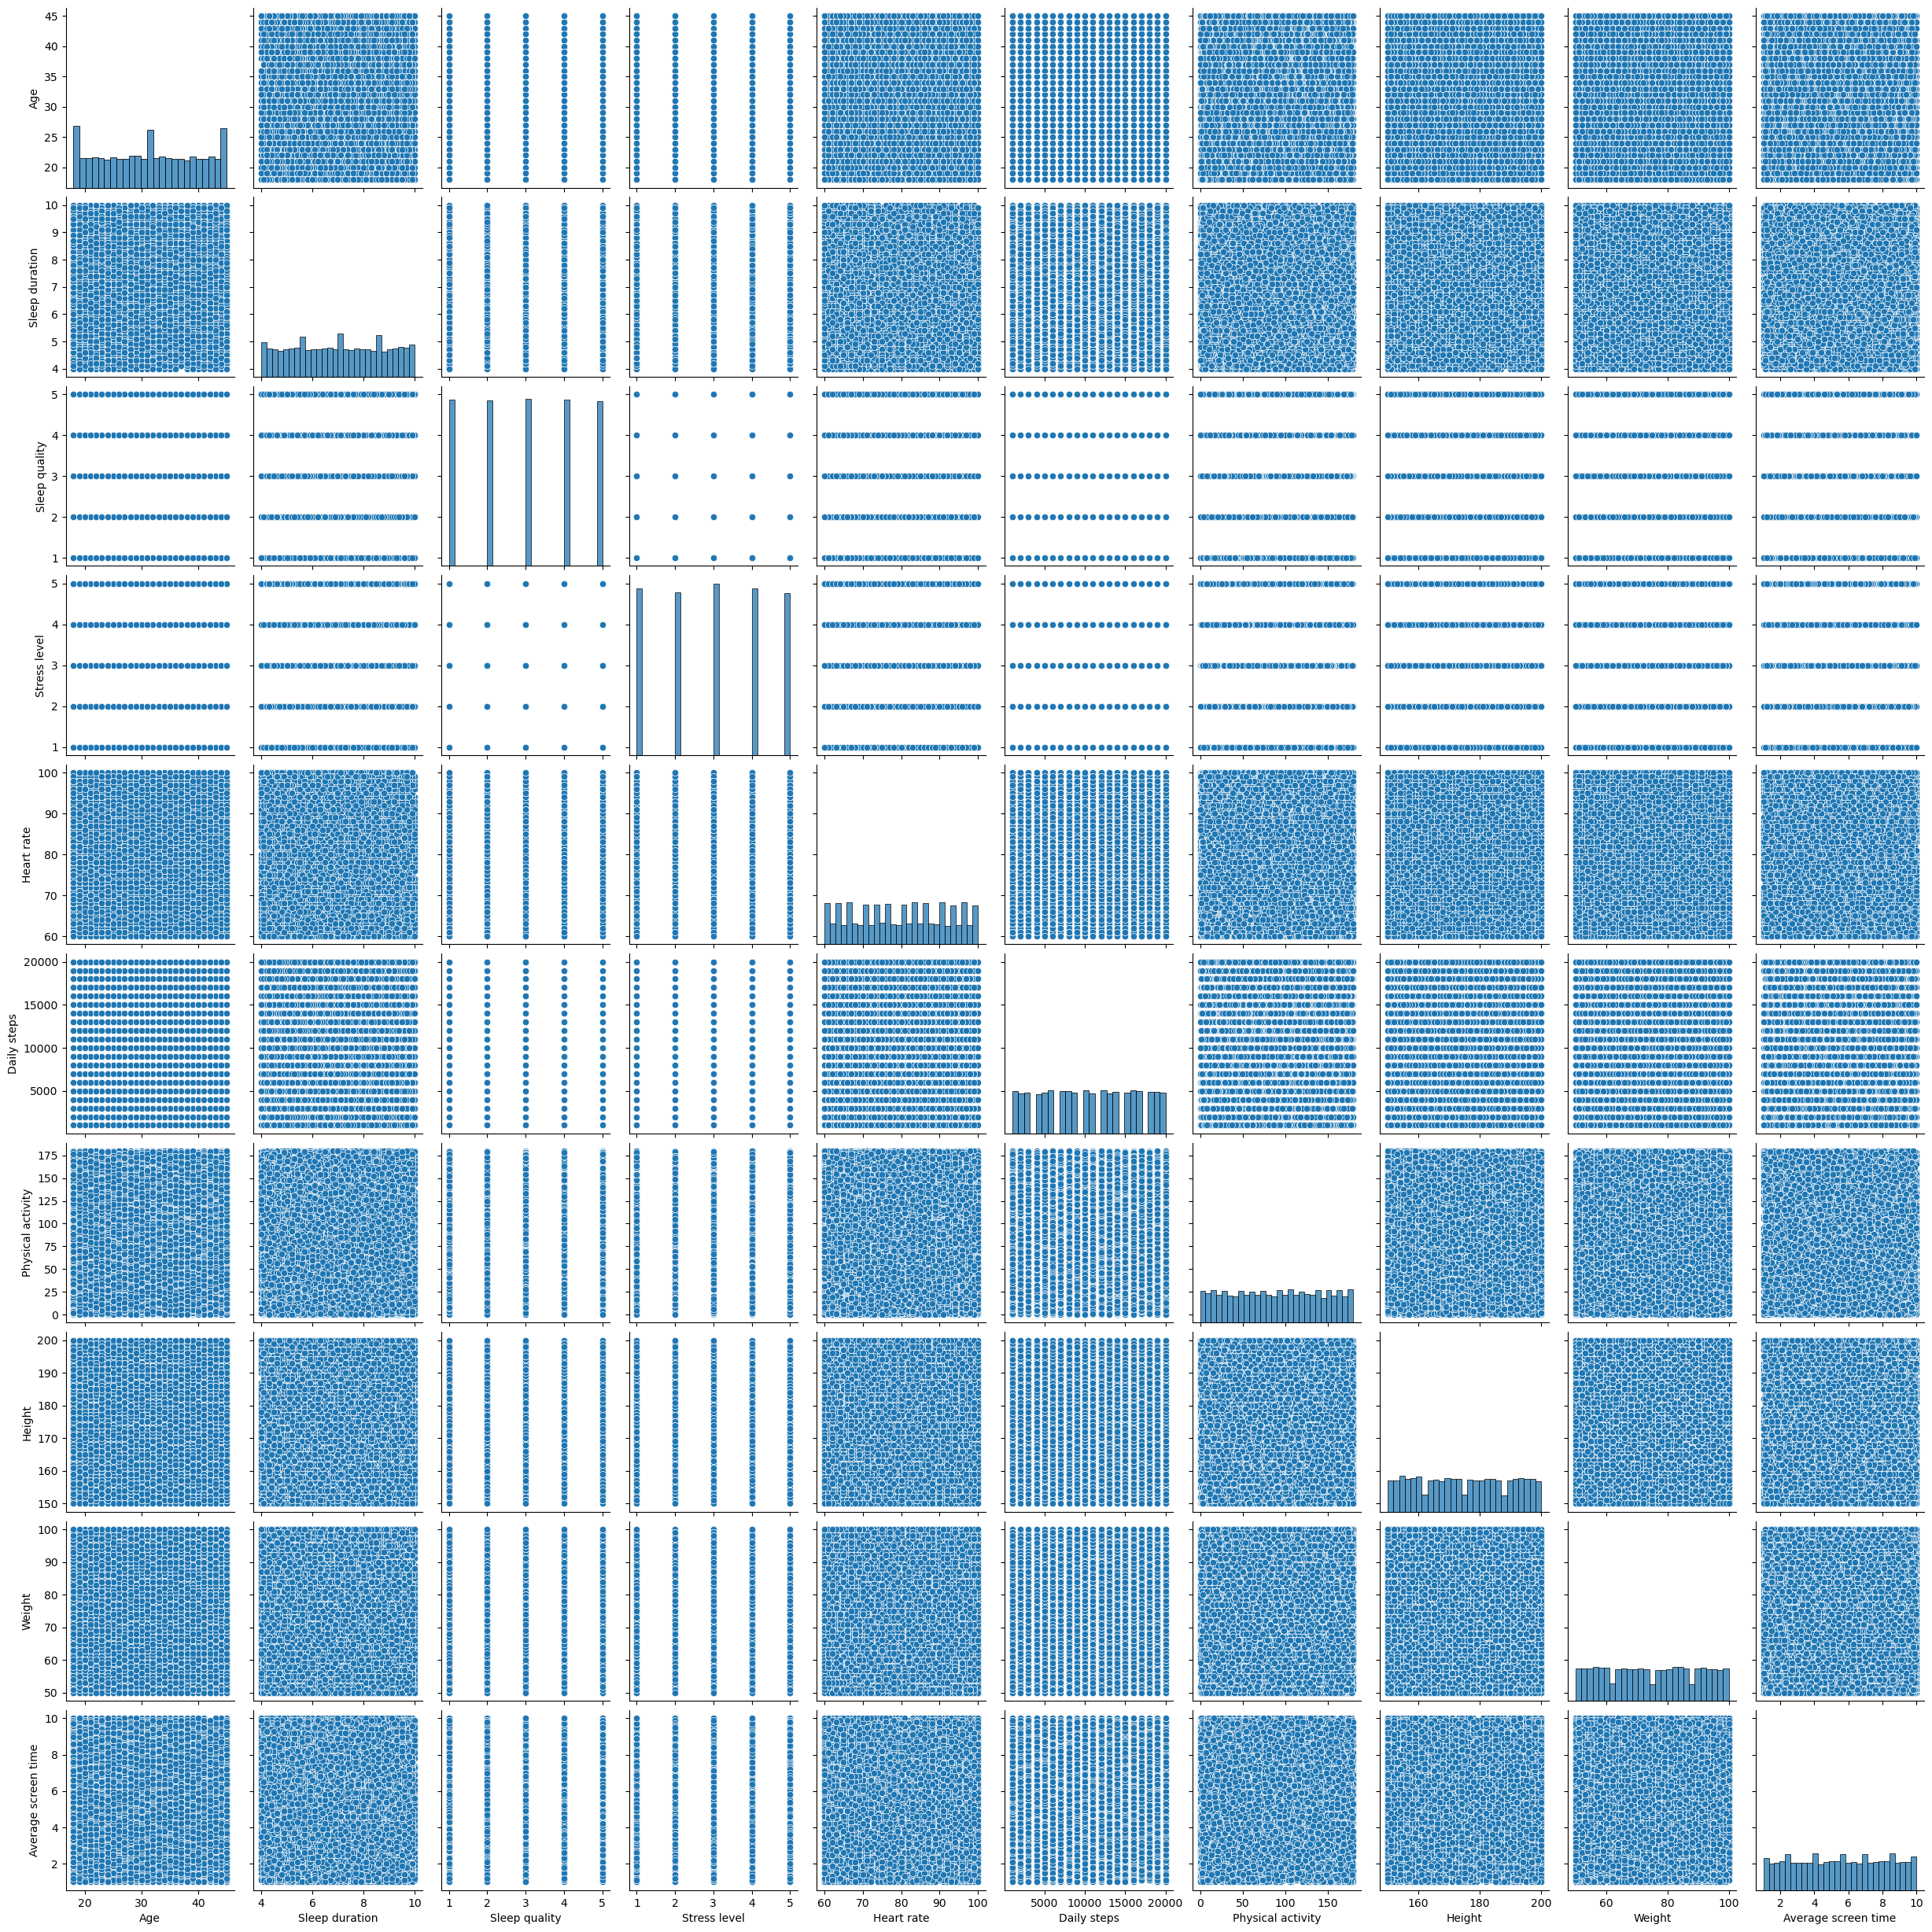

In [30]:
sns.pairplot(df)

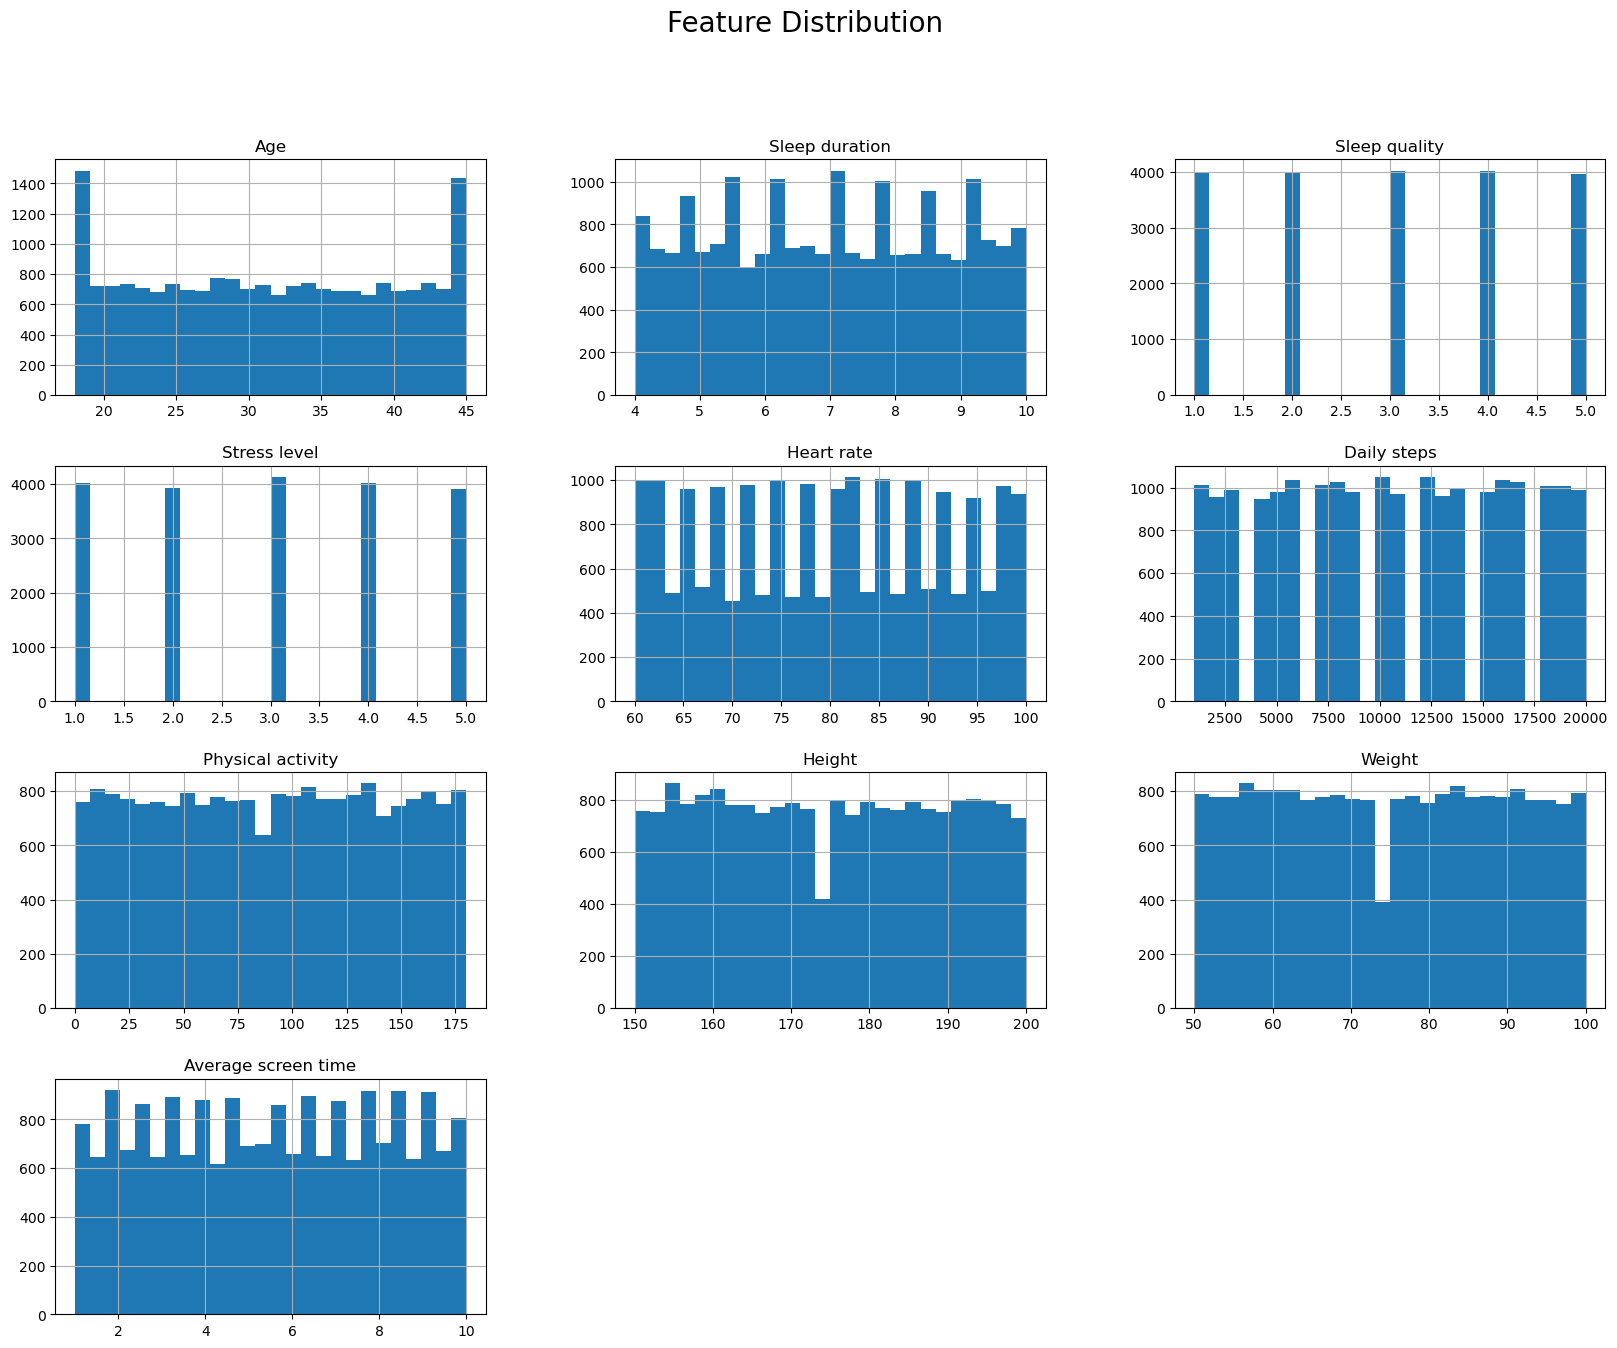

In [31]:
# HISTPLOT
df.hist(figsize=(20, 15), bins=26)
plt.suptitle("Feature Distribution", fontsize=20)
plt.show()

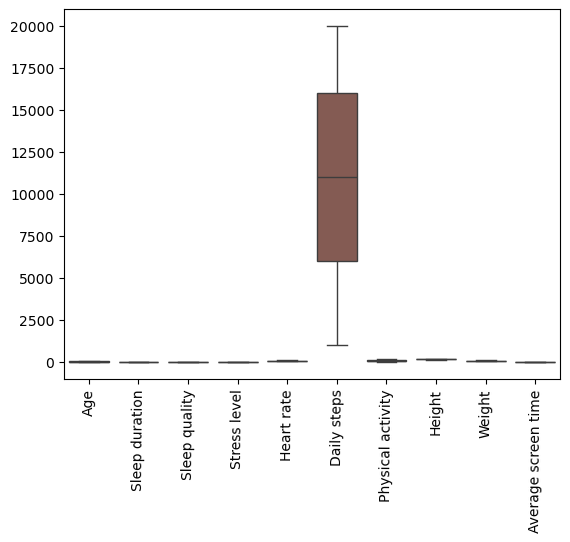

In [32]:
sns.boxplot(df)
plt.xticks(rotation=89.5)
plt.show()

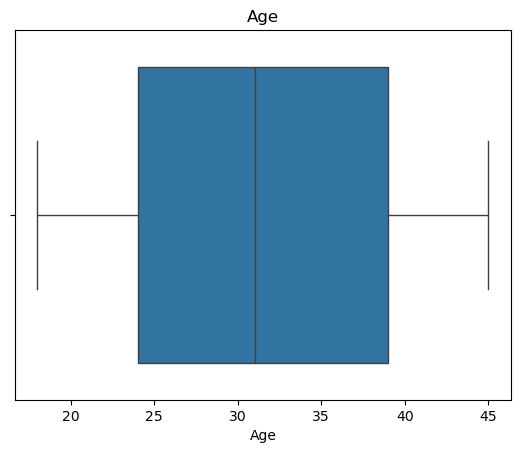

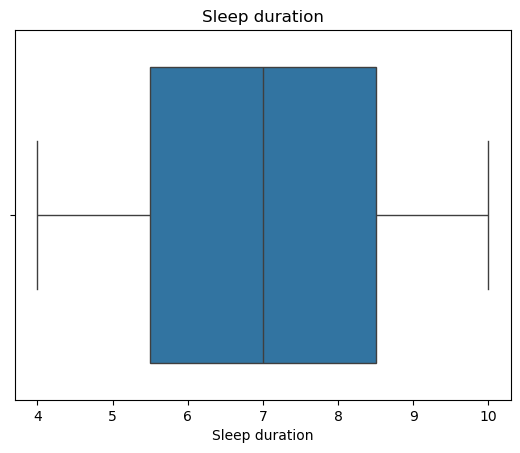

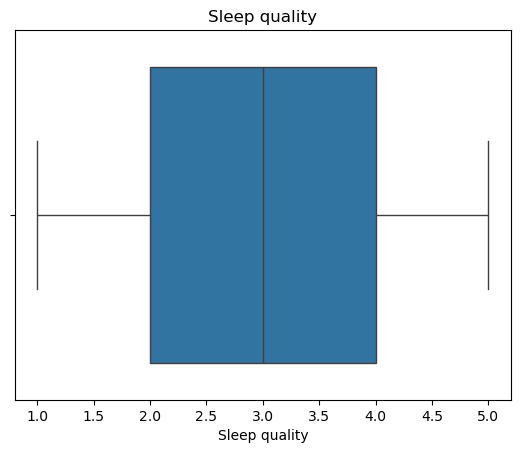

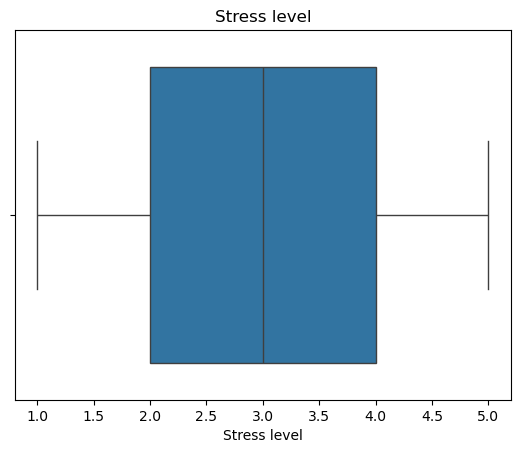

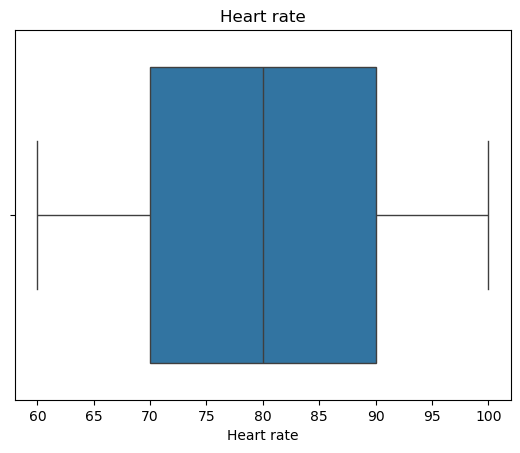

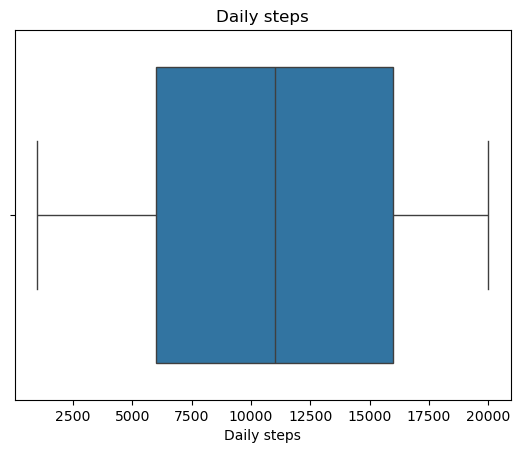

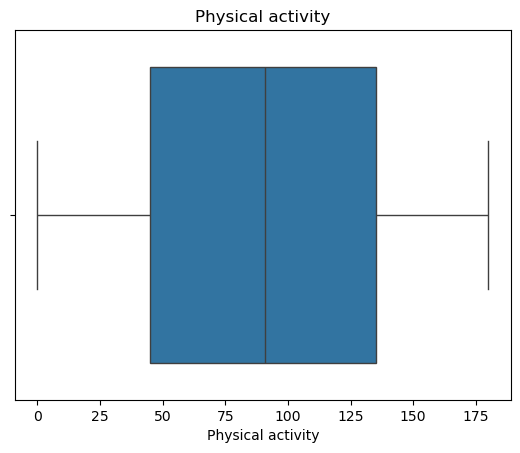

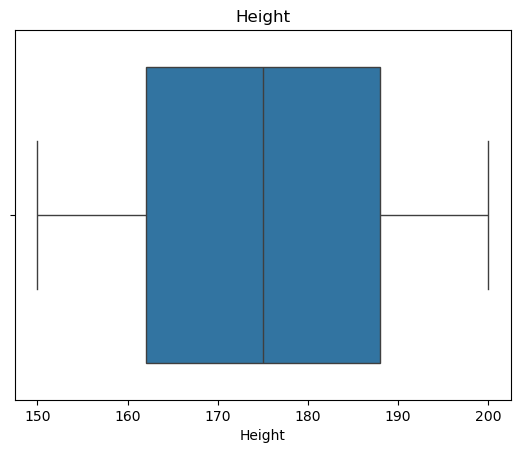

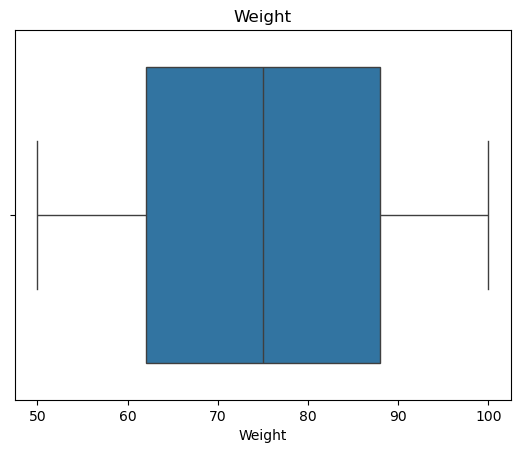

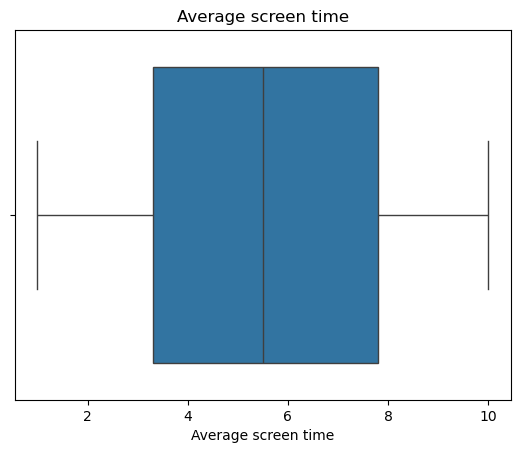

In [33]:
# BOXPLOT
for i in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df,x=i)
    plt.title(i)
    plt.show()

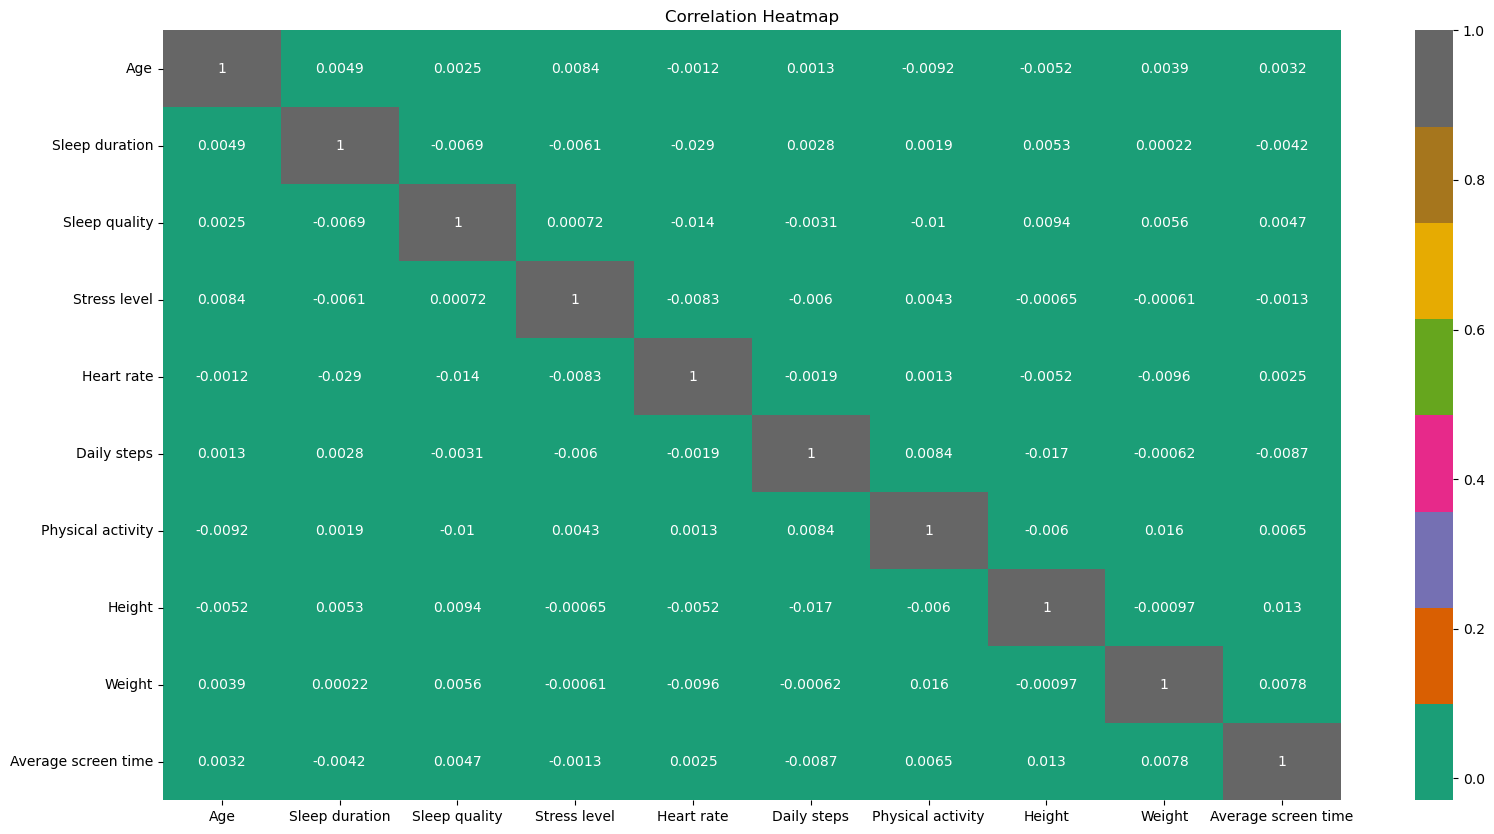

In [34]:
plt.figure(figsize=(19,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Dark2')
plt.title("Correlation Heatmap")
plt.show()

# PREPROCESSING

In [36]:
df.dtypes

Gender                          object
Age                              int64
Sleep duration                 float64
Sleep quality                    int64
Stress level                     int64
Blood pressure                  object
Heart rate                       int64
Daily steps                      int64
Physical activity                int64
Height                           int64
Weight                           int64
Sleep disorder                  object
Wake up during night            object
Feel sleepy during day          object
Caffeine consumption            object
Alcohol consumption             object
Smoking                         object
Medical issue                   object
Ongoing medication              object
Smart device before bed         object
Average screen time            float64
Blue-light filter               object
Discomfort Eye-strain           object
Redness in eye                  object
Itchiness/Irritation in eye     object
Dry Eye Disease          

In [37]:
df.columns

Index(['Gender', 'Age', 'Sleep duration', 'Sleep quality', 'Stress level',
       'Blood pressure', 'Heart rate', 'Daily steps', 'Physical activity',
       'Height', 'Weight', 'Sleep disorder', 'Wake up during night',
       'Feel sleepy during day', 'Caffeine consumption', 'Alcohol consumption',
       'Smoking', 'Medical issue', 'Ongoing medication',
       'Smart device before bed', 'Average screen time', 'Blue-light filter',
       'Discomfort Eye-strain', 'Redness in eye',
       'Itchiness/Irritation in eye', 'Dry Eye Disease'],
      dtype='object')

In [38]:
le0=LabelEncoder()

In [39]:
df['Gender'] = le0.fit_transform(df['Gender'])

In [40]:
le=LabelEncoder()

In [41]:
df['Sleep disorder'] = le.fit_transform(df['Sleep disorder'])

In [42]:
le1=LabelEncoder()

In [43]:
df['Wake up during night'] = le1.fit_transform(df['Wake up during night'])

In [44]:
le2=LabelEncoder()

In [45]:
df['Feel sleepy during day'] = le2.fit_transform(df['Feel sleepy during day'])

In [46]:
le3=LabelEncoder()

In [47]:
df['Caffeine consumption'] = le3.fit_transform(df['Caffeine consumption'])

In [48]:
le4=LabelEncoder()

In [49]:
df['Alcohol consumption'] = le4.fit_transform(df['Alcohol consumption'])

In [50]:
le5=LabelEncoder()

In [51]:
df['Smoking'] = le5.fit_transform(df['Smoking'])

In [81]:
le6=LabelEncoder()

In [83]:
df['Medical issue'] = le6.fit_transform(df['Medical issue'])

In [85]:
le7=LabelEncoder()

In [87]:
df['Ongoing medication'] = le7.fit_transform(df['Ongoing medication'])

In [89]:
le8=LabelEncoder()

In [91]:
df['Smart device before bed'] = le8.fit_transform(df['Smart device before bed'])

In [93]:
le9=LabelEncoder()

In [95]:
df['Blue-light filter'] = le9.fit_transform(df['Blue-light filter'])

In [97]:
le10=LabelEncoder()

In [99]:
df['Discomfort Eye-strain'] = le10.fit_transform(df['Discomfort Eye-strain'])

In [101]:
le11=LabelEncoder()

In [103]:
df['Redness in eye'] = le11.fit_transform(df['Redness in eye'])

In [105]:
le12=LabelEncoder()

In [107]:
df['Itchiness/Irritation in eye'] = le12.fit_transform(df['Itchiness/Irritation in eye'])

In [109]:
le13=LabelEncoder()

In [111]:
df['Dry Eye Disease'] = le13.fit_transform(df['Dry Eye Disease'])

In [113]:
df.dtypes

Gender                           int32
Age                              int64
Sleep duration                 float64
Sleep quality                    int64
Stress level                     int64
Blood pressure                  object
Heart rate                       int64
Daily steps                      int64
Physical activity                int64
Height                           int64
Weight                           int64
Sleep disorder                   int32
Wake up during night             int32
Feel sleepy during day           int32
Caffeine consumption             int32
Alcohol consumption              int32
Smoking                          int32
Medical issue                    int64
Ongoing medication               int64
Smart device before bed          int32
Average screen time            float64
Blue-light filter                int32
Discomfort Eye-strain            int32
Redness in eye                   int32
Itchiness/Irritation in eye      int32
Dry Eye Disease          

In [115]:
df=df.drop(['Blood pressure'],axis=1)
df

,Gender,Age,Sleep duration,Sleep quality,Stress level,Heart rate,Daily steps,Physical activity,Height,Weight,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
0,0,24,9.5,2,1,67,3000,31,161,69,...,0,1,1,0,8.7,0,1,1,0,1
1,1,39,9.6,2,3,60,12000,74,164,87,...,0,1,1,0,9.6,1,0,0,1,1
2,0,45,5.4,1,5,95,12000,93,179,94,...,0,0,0,1,4.0,0,1,0,0,0
3,0,45,5.4,4,5,78,19000,32,160,77,...,0,1,0,0,7.6,0,1,0,1,0
4,0,42,5.7,3,2,72,4000,173,179,99,...,0,1,0,0,3.5,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1,26,9.4,2,3,91,20000,88,200,72,...,1,1,1,1,3.8,0,1,0,1,1
19996,0,39,7.3,3,4,65,2000,53,195,96,...,0,1,1,0,3.8,0,0,1,0,1
19997,0,20,8.0,5,3,78,10000,17,186,87,...,1,1,0,0,8.4,0,0,1,0,0
19998,1,38,4.5,3,3,60,3000,115,170,66,...,1,0,1,0,2.2,0,0,0,1,1


In [117]:
x = df.drop('Dry Eye Disease',axis=1)
y = df[['Dry Eye Disease']]

In [119]:
x

,Gender,Age,Sleep duration,Sleep quality,Stress level,Heart rate,Daily steps,Physical activity,Height,Weight,...,Alcohol consumption,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye
0,0,24,9.5,2,1,67,3000,31,161,69,...,0,0,1,1,0,8.7,0,1,1,0
1,1,39,9.6,2,3,60,12000,74,164,87,...,1,0,1,1,0,9.6,1,0,0,1
2,0,45,5.4,1,5,95,12000,93,179,94,...,1,0,0,0,1,4.0,0,1,0,0
3,0,45,5.4,4,5,78,19000,32,160,77,...,0,0,1,0,0,7.6,0,1,0,1
4,0,42,5.7,3,2,72,4000,173,179,99,...,0,0,1,0,0,3.5,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1,26,9.4,2,3,91,20000,88,200,72,...,0,1,1,1,1,3.8,0,1,0,1
19996,0,39,7.3,3,4,65,2000,53,195,96,...,1,0,1,1,0,3.8,0,0,1,0
19997,0,20,8.0,5,3,78,10000,17,186,87,...,1,1,1,0,0,8.4,0,0,1,0
19998,1,38,4.5,3,3,60,3000,115,170,66,...,1,1,0,1,0,2.2,0,0,0,1


In [121]:
y

,Dry Eye Disease
0,1
1,1
2,0
3,0
4,1
...,...
19995,1
19996,1
19997,0
19998,1


#### SCALING

In [124]:
sc=StandardScaler()
x=sc.fit_transform(x)

## TRAIN TEST SPLIT

In [127]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=60)

## LOGISTIC REGRESSION

Test score: 0.6832
train score: 0.685
CR:               precision    recall  f1-score   support

           0       0.66      0.16      0.26      1714
           1       0.69      0.96      0.80      3286

    accuracy                           0.68      5000
   macro avg       0.67      0.56      0.53      5000
weighted avg       0.68      0.68      0.61      5000

Test accuracy: 68.32000000000001
Train accuracy: 68.5


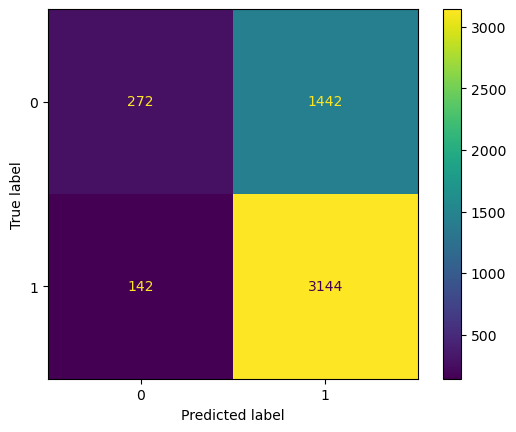

In [130]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_testpred=lr.predict(x_test)
y_trainpred=lr.predict(x_train)
print('Test score:',lr.score(x_test,y_test))
print('train score:',lr.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
lrt=accuracy_score(y_test,y_testpred)*100
lrr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',lrt)
print('Train accuracy:',lrr)

### DECISION TREE

Test accuracy: 0.5868
train accuracy: 1.0
CR:               precision    recall  f1-score   support

           0       0.40      0.41      0.40      1714
           1       0.69      0.68      0.68      3286

    accuracy                           0.59      5000
   macro avg       0.54      0.54      0.54      5000
weighted avg       0.59      0.59      0.59      5000

Test accuracy: 58.68
Train accuracy: 100.0


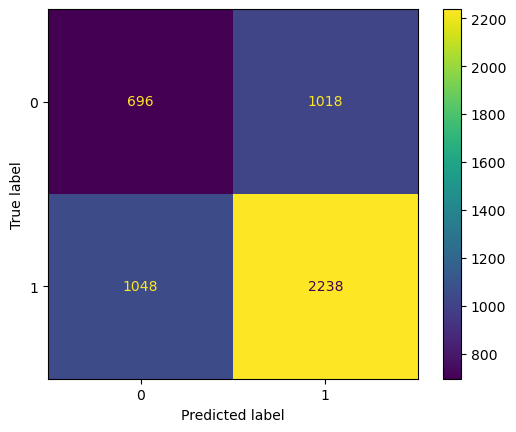

In [133]:
dt=DecisionTreeClassifier(criterion='entropy')
dt.fit(x_train,y_train)
y_testpred=dt.predict(x_test)
y_trainpred=dt.predict(x_train)
print('Test accuracy:',dt.score(x_test,y_test))
print('train accuracy:',dt.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
dtt=accuracy_score(y_test,y_testpred)*100
dtr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',dtt)
print('Train accuracy:',dtr)

### RANDOM FOREST CLASSIFIER

Test accuracy: 0.6116
train accuracy: 0.9597333333333333
CR:               precision    recall  f1-score   support

           0       0.42      0.33      0.37      1714
           1       0.68      0.76      0.72      3286

    accuracy                           0.61      5000
   macro avg       0.55      0.54      0.54      5000
weighted avg       0.59      0.61      0.60      5000

Test accuracy: 61.160000000000004
Train accuracy: 95.97333333333333


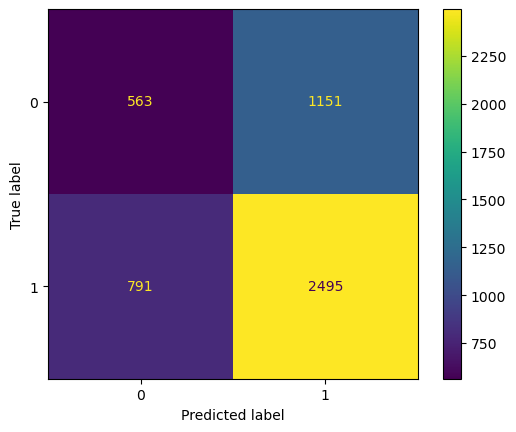

In [136]:
rf=RandomForestClassifier(n_estimators=5,random_state=10)
rf.fit(x_train,y_train)
y_testpred=rf.predict(x_test)
y_trainpred=rf.predict(x_train)
print('Test accuracy:',rf.score(x_test,y_test))
print('train accuracy:',rf.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
rft=accuracy_score(y_test,y_testpred)*100
rfr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',rft)
print('Train accuracy:',rfr)

### X-G BOOST

Test accuracy: 0.6588
train accuracy: 0.8994
CR:               precision    recall  f1-score   support

           0       0.50      0.30      0.37      1714
           1       0.70      0.85      0.77      3286

    accuracy                           0.66      5000
   macro avg       0.60      0.57      0.57      5000
weighted avg       0.63      0.66      0.63      5000

Test accuracy: 65.88000000000001
Train accuracy: 89.94


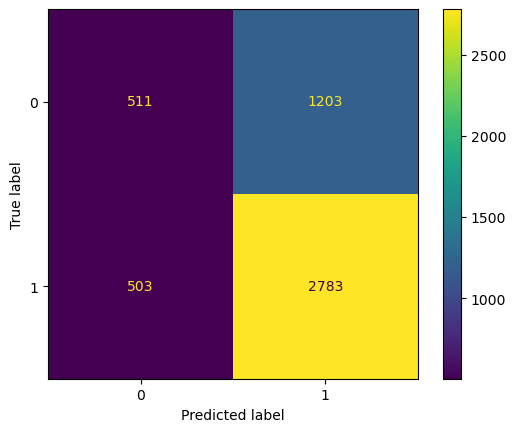

In [139]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)
y_testpred=xgb.predict(x_test)
y_trainpred=xgb.predict(x_train)
print('Test accuracy:',xgb.score(x_test,y_test))
print('train accuracy:',xgb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
xgt=accuracy_score(y_test,y_testpred)*100
xgr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',xgt)
print('Train accuracy:',xgr)

### SVM

Test score: 0.6988
train score: 0.6982
CR:               precision    recall  f1-score   support

           0       0.67      0.24      0.35      1714
           1       0.70      0.94      0.80      3286

    accuracy                           0.70      5000
   macro avg       0.69      0.59      0.58      5000
weighted avg       0.69      0.70      0.65      5000

Test accuracy: 69.88
Train accuracy: 69.82000000000001


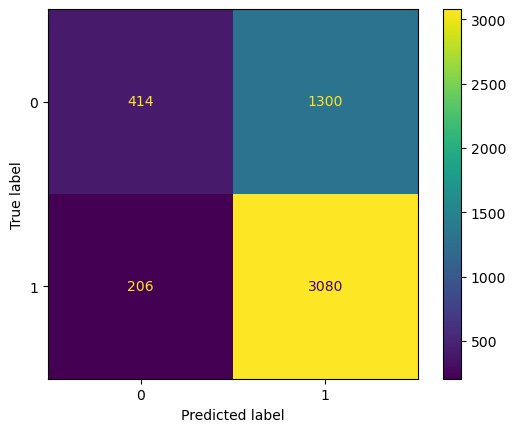

In [142]:
sv=SVC()
sv.fit(x_train,y_train)
y_testpred=sv.predict(x_test)
y_trainpred=sv.predict(x_train)
print('Test score:',sv.score(x_test,y_test))
print('train score:',sv.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
svt=accuracy_score(y_test,y_testpred)*100
svr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',svt)
print('Train accuracy:',svr)

# KNN

Test accuracy: 0.5964
train accuracy: 0.7892
CR:               precision    recall  f1-score   support

           0       0.39      0.32      0.36      1714
           1       0.68      0.74      0.71      3286

    accuracy                           0.60      5000
   macro avg       0.53      0.53      0.53      5000
weighted avg       0.58      0.60      0.59      5000

Test accuracy: 59.64
Train accuracy: 78.92


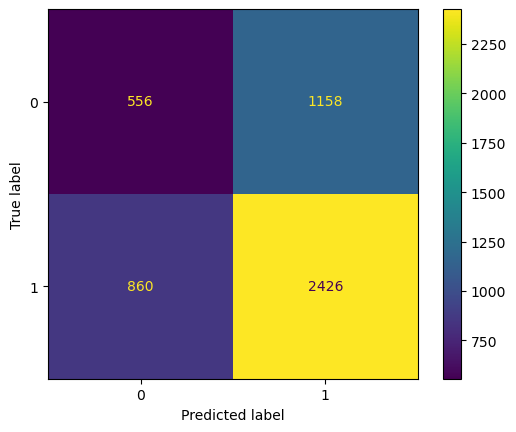

In [145]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_testpred=knn.predict(x_test)
y_trainpred=knn.predict(x_train)
print('Test accuracy:',knn.score(x_test,y_test))
print('train accuracy:',knn.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
knnt=accuracy_score(y_test,y_testpred)*100
knnr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',knnt)
print('Train accuracy:',knnr)

## NAIVE BAYES

Test accuracy: 0.6856
train accuracy: 0.6838
CR:               precision    recall  f1-score   support

           0       0.68      0.16      0.26      1714
           1       0.69      0.96      0.80      3286

    accuracy                           0.69      5000
   macro avg       0.68      0.56      0.53      5000
weighted avg       0.68      0.69      0.61      5000

Test accuracy: 68.56
Train accuracy: 68.38


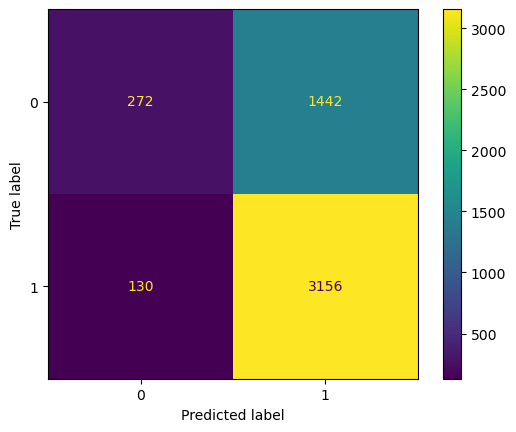

In [147]:
gb=GaussianNB()
gb.fit(x_train,y_train)
y_testpred=gb.predict(x_test)
y_trainpred=gb.predict(x_train)
print('Test accuracy:',gb.score(x_test,y_test))
print('train accuracy:',gb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
gbt=accuracy_score(y_test,y_testpred)*100
gbr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',gbt)
print('Train accuracy:',gbr)

### ADABOOST

Test accuracy: 0.6572
train accuracy: 0.6500666666666667
CR:               precision    recall  f1-score   support

           0       0.00      0.00      0.00      1714
           1       0.66      1.00      0.79      3286

    accuracy                           0.66      5000
   macro avg       0.33      0.50      0.40      5000
weighted avg       0.43      0.66      0.52      5000

Test accuracy: 65.72
Train accuracy: 65.00666666666667


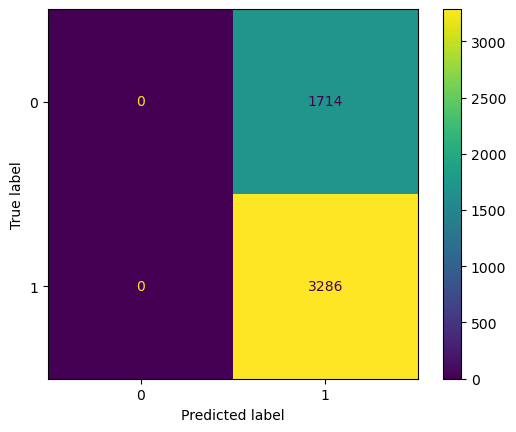

In [150]:
adaboost=AdaBoostClassifier(n_estimators=10,estimator=None,learning_rate=0.2,random_state=5)
adaboost.fit(x_train,y_train)
y_testpred=adaboost.predict(x_test)
y_trainpred=adaboost.predict(x_train)
print('Test accuracy:',adaboost.score(x_test,y_test))
print('train accuracy:',adaboost.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
adt=accuracy_score(y_test,y_testpred)*100
adr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',adt)
print('Train accuracy:',adr)

### GRADIENT BOOSTING

Test accuracy: 0.699
train accuracy: 0.6978
CR:               precision    recall  f1-score   support

           0       0.67      0.24      0.36      1714
           1       0.70      0.94      0.80      3286

    accuracy                           0.70      5000
   macro avg       0.69      0.59      0.58      5000
weighted avg       0.69      0.70      0.65      5000

Test accuracy: 69.89999999999999
Train accuracy: 69.78


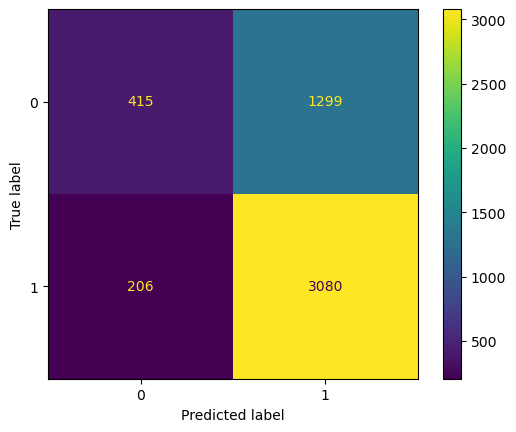

In [154]:
gbc=GradientBoostingClassifier(n_estimators=100,learning_rate=0.05,random_state=200)
gbc.fit(x_train,y_train)
y_testpred=gbc.predict(x_test)
y_trainpred=gbc.predict(x_train)
print('Test accuracy:',gbc.score(x_test,y_test))
print('train accuracy:',gbc.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
gbt=accuracy_score(y_test,y_testpred)*100
gbr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',gbt)
print('Train accuracy:',gbr)

# INITIAL PERFORMANCE

In [156]:
tb=pd.DataFrame()
tb['model']=pd.Series(['knn','lr','gb','rf','adaboost','gbc','dt','xgb','sv'])
tb['test_accuracy']=pd.Series([knnt,lrt,gbt,rft,adt,gbt,dtt,xgt,svt])
tb['train_accuracy']=pd.Series([knnr,lrr,gbr,rfr,adr,gbr,dtr,xgr,svr])
tb

,model,test_accuracy,train_accuracy
0,knn,59.64,78.920000
1,lr,68.32,68.500000
2,gb,69.90,69.780000
3,rf,61.16,95.973333
4,adaboost,65.72,65.006667
5,gbc,69.90,69.780000
6,dt,58.68,100.000000
7,xgb,65.88,89.940000
8,sv,69.88,69.820000


# BALANCING OF DATA

In [160]:
from imblearn.over_sampling import SMOTE
#from collections import Counter
# Apply SMOTE
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x,y)
y_resampled.value_counts()


Dry Eye Disease
0                  13037
1                  13037
Name: count, dtype: int64

# TRAIN TEST SPLIT AFTER SMOTE

In [163]:
x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.25,random_state=60)

### LOGISTIC REGRESSION

Test score: 0.5660377358490566
train score: 0.5577090258245972
CR:               precision    recall  f1-score   support

           0       0.56      0.59      0.57      3245
           1       0.57      0.55      0.56      3274

    accuracy                           0.57      6519
   macro avg       0.57      0.57      0.57      6519
weighted avg       0.57      0.57      0.57      6519

Test accuracy: 56.60377358490566
Train accuracy: 55.770902582459726


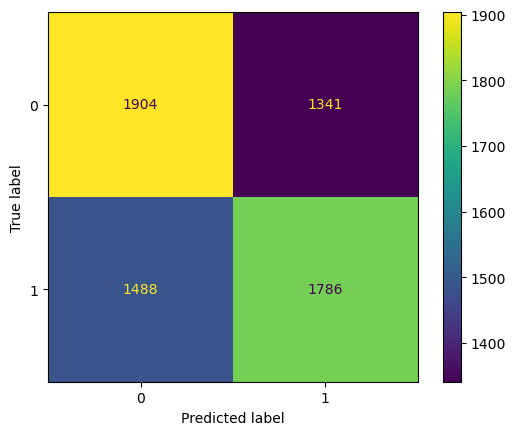

In [166]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_testpred=lr.predict(x_test)
y_trainpred=lr.predict(x_train)
print('Test score:',lr.score(x_test,y_test))
print('train score:',lr.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
lrt=accuracy_score(y_test,y_testpred)*100
lrr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',lrt)
print('Train accuracy:',lrr)

### DECISION TREE

Test accuracy: 0.661911336094493
train accuracy: 1.0
CR:               precision    recall  f1-score   support

           0       0.65      0.68      0.67      3245
           1       0.67      0.64      0.66      3274

    accuracy                           0.66      6519
   macro avg       0.66      0.66      0.66      6519
weighted avg       0.66      0.66      0.66      6519

Test accuracy: 66.19113360944931
Train accuracy: 100.0


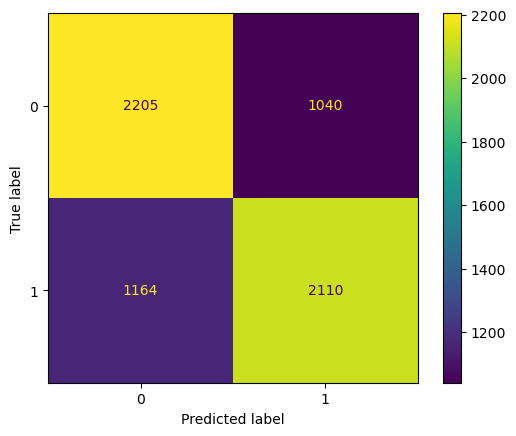

In [169]:
dt=DecisionTreeClassifier(criterion='entropy')
dt.fit(x_train,y_train)
y_testpred=dt.predict(x_test)
y_trainpred=dt.predict(x_train)
print('Test accuracy:',dt.score(x_test,y_test))
print('train accuracy:',dt.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
dtt=accuracy_score(y_test,y_testpred)*100
dtr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',dtt)
print('Train accuracy:',dtr)

### RANDOM FOREST CLASSIFIER

Test accuracy: 0.6840006135910416
train accuracy: 0.9681922781897213
CR:               precision    recall  f1-score   support

           0       0.69      0.66      0.67      3245
           1       0.68      0.71      0.69      3274

    accuracy                           0.68      6519
   macro avg       0.68      0.68      0.68      6519
weighted avg       0.68      0.68      0.68      6519

Test accuracy: 68.40006135910416
Train accuracy: 96.81922781897214


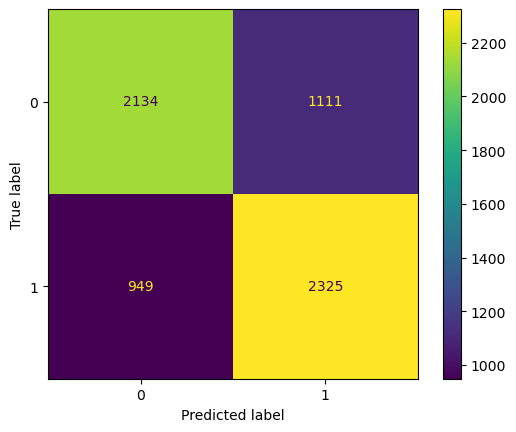

In [172]:
rf=RandomForestClassifier(n_estimators=5,random_state=10)
rf.fit(x_train,y_train)
y_testpred=rf.predict(x_test)
y_trainpred=rf.predict(x_train)
print('Test accuracy:',rf.score(x_test,y_test))
print('train accuracy:',rf.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
rft=accuracy_score(y_test,y_testpred)*100
rfr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',rft)
print('Train accuracy:',rfr)

### XG BOOST

Test accuracy: 0.7461267065500844
train accuracy: 0.9022244950140629
CR:               precision    recall  f1-score   support

           0       0.82      0.63      0.71      3245
           1       0.70      0.86      0.77      3274

    accuracy                           0.75      6519
   macro avg       0.76      0.75      0.74      6519
weighted avg       0.76      0.75      0.74      6519

Test accuracy: 74.61267065500844
Train accuracy: 90.22244950140629


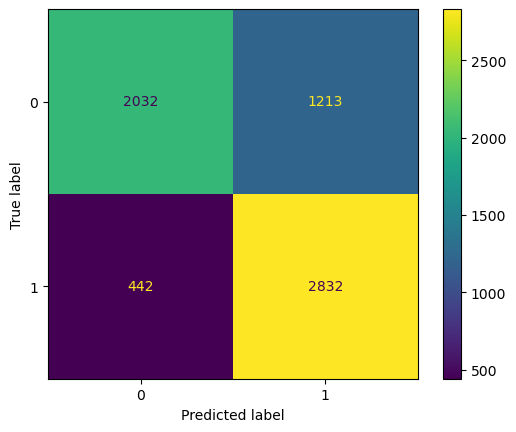

In [175]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)
y_testpred=xgb.predict(x_test)
y_trainpred=xgb.predict(x_train)
print('Test accuracy:',xgb.score(x_test,y_test))
print('train accuracy:',xgb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
xgt=accuracy_score(y_test,y_testpred)*100
xgr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',xgt)
print('Train accuracy:',xgr)

# SVM

Test score: 0.7126859947844761
train score: 0.7963692150345181
CR:               precision    recall  f1-score   support

           0       0.76      0.62      0.68      3245
           1       0.68      0.80      0.74      3274

    accuracy                           0.71      6519
   macro avg       0.72      0.71      0.71      6519
weighted avg       0.72      0.71      0.71      6519

Test accuracy: 71.26859947844761
Train accuracy: 79.6369215034518


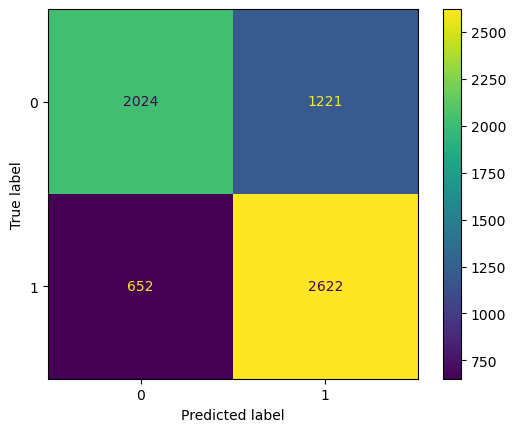

In [178]:
sv=SVC()
sv.fit(x_train,y_train)
y_testpred=sv.predict(x_test)
y_trainpred=sv.predict(x_train)
print('Test score:',sv.score(x_test,y_test))
print('train score:',sv.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
svt=accuracy_score(y_test,y_testpred)*100
svr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',svt)
print('Train accuracy:',svr)

# KNN

Test accuracy: 0.6632919159380273
train accuracy: 0.8299156226029148
CR:               precision    recall  f1-score   support

           0       0.62      0.84      0.71      3245
           1       0.75      0.49      0.59      3274

    accuracy                           0.66      6519
   macro avg       0.69      0.66      0.65      6519
weighted avg       0.69      0.66      0.65      6519

Test accuracy: 66.32919159380273
Train accuracy: 82.99156226029149


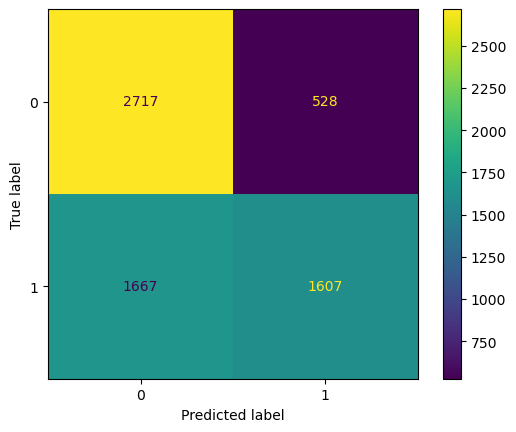

In [181]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_testpred=knn.predict(x_test)
y_trainpred=knn.predict(x_train)
print('Test accuracy:',knn.score(x_test,y_test))
print('train accuracy:',knn.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
knnt=accuracy_score(y_test,y_testpred)*100
knnr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',knnt)
print('Train accuracy:',knnr)

# NAIVE BAYES

Test accuracy: 0.5948765148028838
train accuracy: 0.586295065200716
CR:               precision    recall  f1-score   support

           0       0.59      0.60      0.59      3245
           1       0.60      0.59      0.60      3274

    accuracy                           0.59      6519
   macro avg       0.59      0.59      0.59      6519
weighted avg       0.59      0.59      0.59      6519

Test accuracy: 59.487651480288385
Train accuracy: 58.629506520071594


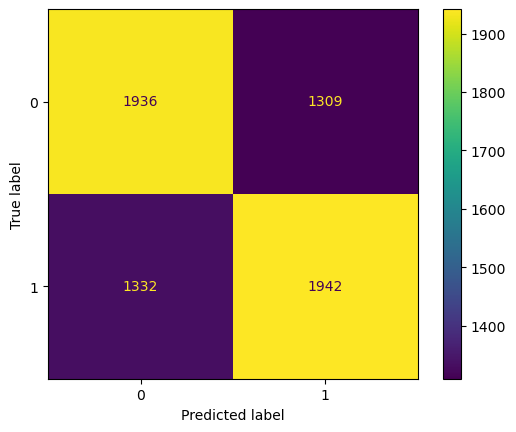

In [183]:
gb=GaussianNB()
gb.fit(x_train,y_train)
y_testpred=gb.predict(x_test)
y_trainpred=gb.predict(x_train)
print('Test accuracy:',gb.score(x_test,y_test))
print('train accuracy:',gb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
gbt=accuracy_score(y_test,y_testpred)*100
gbr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',gbt)
print('Train accuracy:',gbr)

# ADABOOST

Test accuracy: 0.5850590581377512
train accuracy: 0.5766300178982358
CR:               precision    recall  f1-score   support

           0       0.58      0.63      0.60      3245
           1       0.60      0.54      0.57      3274

    accuracy                           0.59      6519
   macro avg       0.59      0.59      0.58      6519
weighted avg       0.59      0.59      0.58      6519

Test accuracy: 58.505905813775115
Train accuracy: 57.663001789823575


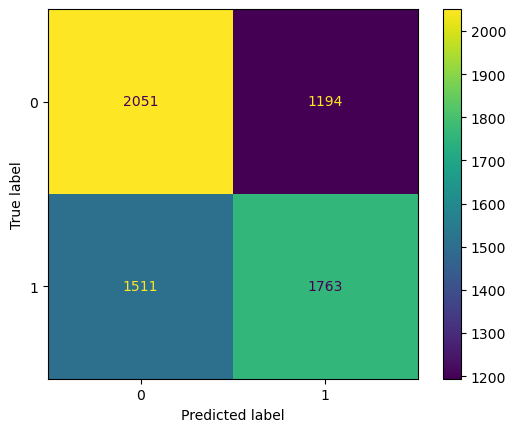

In [187]:
adaboost=AdaBoostClassifier(n_estimators=10,estimator=None,learning_rate=0.2,random_state=5)
adaboost.fit(x_train,y_train)
y_testpred=adaboost.predict(x_test)
y_trainpred=adaboost.predict(x_train)
print('Test accuracy:',adaboost.score(x_test,y_test))
print('train accuracy:',adaboost.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
adt=accuracy_score(y_test,y_testpred)*100
adr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',adt)
print('Train accuracy:',adr)

# GRADIENT BOOSTING

Test accuracy: 0.750882037122258
train accuracy: 0.7462541549475837
CR:               precision    recall  f1-score   support

           0       0.90      0.56      0.69      3245
           1       0.68      0.94      0.79      3274

    accuracy                           0.75      6519
   macro avg       0.79      0.75      0.74      6519
weighted avg       0.79      0.75      0.74      6519

Test accuracy: 75.0882037122258
Train accuracy: 74.62541549475837


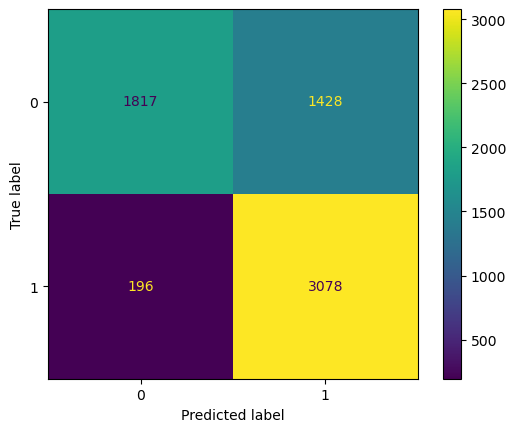

In [190]:
gbc=GradientBoostingClassifier(n_estimators=100,learning_rate=0.05,random_state=200)
gbc.fit(x_train,y_train)
y_testpred=gbc.predict(x_test)
y_trainpred=gbc.predict(x_train)
print('Test accuracy:',gbc.score(x_test,y_test))
print('train accuracy:',gbc.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
gbt=accuracy_score(y_test,y_testpred)*100
gbr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',gbt)
print('Train accuracy:',gbr)

# PERFORMANCE AFTER SMOTE

In [192]:
tb=pd.DataFrame()
tb['model']=pd.Series(['knn','lr','gb','rf','adaboost','gbc','dt','xgb','sv'])
tb['test_accuracy']=pd.Series([knnt,lrt,gbt,rft,adt,gbt,dtt,xgt,svt])
tb['train_accuracy']=pd.Series([knnr,lrr,gbr,rfr,adr,gbr,dtr,xgr,svr])
tb

,model,test_accuracy,train_accuracy
0,knn,66.329192,82.991562
1,lr,56.603774,55.770903
2,gb,75.088204,74.625415
3,rf,68.400061,96.819228
4,adaboost,58.505906,57.663002
5,gbc,75.088204,74.625415
6,dt,66.191134,100.000000
7,xgb,74.612671,90.222450
8,sv,71.268599,79.636922


# HYPERPARAMETER TUNNING

In [196]:
# RANDOM FOREST
# ------------------
rf_params={'n_estimators':[10,50,100],'max_depth':[2,4,6,None]}
rf_grid=GridSearchCV(RandomForestClassifier(random_state=42),rf_params,cv=5)
rf_grid.fit(x_train,y_train)
           

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [2, 4, 6, None],
                         'n_estimators': [10, 50, 100]})

In [197]:
# # SVM
# # -------
# svm_params={'C':[0.1,1,10],'kernel':['linear','rbf'],'gamma':['scale','auto']}
# svm_grid=GridSearchCV(SVC(),svm_params,cv=5)
# svm_grid.fit(x_train,y_train)

In [200]:
# DECISION TREE
# ------------------
dt_params={'max_depth':[2,4,6,None],'criterion':['gini','entropy']}
dt_grid=GridSearchCV(DecisionTreeClassifier(random_state=42),dt_params,cv=5)
dt_grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, None]})

In [201]:
# LOGITIC REGRESSION
# ----------------------
ir_params={'C':[0.1,1,10]}
ir_grid=GridSearchCV(LogisticRegression(),ir_params,cv=5)
ir_grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.1, 1, 10]})

In [204]:
# KNN
knn_param = {
    'n_neighbors':range(1, 31),  # Number of neighbors
    'weights':['uniform','distance'],  # Voting strategy
    'metric':['euclidean','manhattan','minkowski']  # Distance metric
}
knn_grid= GridSearchCV(knn,knn_param,cv=5,scoring='accuracy', n_jobs=-1)
knn_grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=3), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': range(1, 31),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [206]:
# gb
xgb_param = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}
xgb_grid = GridSearchCV(xgb,xgb_param , cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [208]:
models = {'Random Forest': rf_grid,'Logistic Regression': ir_grid,'Decision Tree': dt_grid,'KNN':knn_grid,'XGB':xgb_grid}
for name, grid in models.items():
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}:")
    print(f"  Best Params: {grid.best_params_}")
    print(f"  Accuracy: {acc:.4f}\n")

Random Forest:
  Best Params: {'max_depth': None, 'n_estimators': 100}
  Accuracy: 0.7780

Logistic Regression:
  Best Params: {'C': 0.1}
  Accuracy: 0.5660

Decision Tree:
  Best Params: {'criterion': 'gini', 'max_depth': 6}
  Accuracy: 0.6733

KNN:
  Best Params: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
  Accuracy: 0.7558

XGB:
  Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
  Accuracy: 0.7685



In [210]:
# Access the best model
best_rf_model = rf_grid.best_estimator_
y_pred = best_rf_model.predict(x_test)

In [212]:
print(best_rf_model)

RandomForestClassifier(random_state=42)


In [216]:
import joblib

# Save model
joblib.dump(best_rf_model, "rf_model.pkl")

# Save scaler
joblib.dump(sc, "scaler.pkl")

# Save all label encoders together
label_encoders = {
    "Gender": le0,
    "Sleep disorder": le,
    "Wake up during night": le1,
    "Feel sleepy during day": le2,
    "Caffeine consumption": le3,
    "Alcohol consumption": le4,
    "Smoking": le5,
    "Medical issue": le6,
    "Ongoing medication": le7,
    "Smart device before bed": le8,
    "Blue-light filter": le9,
    "Discomfort Eye-strain": le10,
    "Redness in eye": le11,
    "Itchiness/Irritation in eye": le12
}

joblib.dump(label_encoders, "label_encoders.pkl")

# Save target encoder separately
joblib.dump(le13, "target_encoder.pkl")



['target_encoder.pkl']